# Benin GDELT 2025 - Insights
This notebook explores how Benin is perceived internationally and highlights signals about diplomacy, tourism, and investment using the cleaned GDELT dataset.

In [9]:
import csv
from collections import defaultdict
from statistics import mean

FILE_PATH = "../data/GDELT_events_benin_2025_cleaned.csv"

def load_rows(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return list(csv.DictReader(f))

def to_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None

rows = load_rows(FILE_PATH)
print(f"Rows loaded: {len(rows)}")

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False
    print("matplotlib not available; charts will be skipped.")

Rows loaded: 23967


In [10]:
tones = [to_float(r.get("AvgTone")) for r in rows]
tones = [t for t in tones if t is not None]
gold = [to_float(r.get("GoldsteinScale")) for r in rows]
gold = [g for g in gold if g is not None]

print("Overall coverage")
print(f"- Events: {len(rows)}")
print(f"- AvgTone (mean): {mean(tones):.2f}")
print(f"- GoldsteinScale (mean): {mean(gold):.2f}")

Overall coverage
- Events: 23967
- AvgTone (mean): -1.23
- GoldsteinScale (mean): 0.83


Top foreign countries engaging with Benin
- Nigeria: 2250 events, AvgTone -1.48
- Africa: 757 events, AvgTone -0.31
- France: 552 events, AvgTone -1.62
- West Africa: 399 events, AvgTone -1.58
- Niger: 333 events, AvgTone -3.35
- Ghana: 277 events, AvgTone 0.80
- United States: 224 events, AvgTone -1.06
- Togo: 213 events, AvgTone -0.42
- Burkina Faso: 177 events, AvgTone -3.44
- United Kingdom: 176 events, AvgTone -0.40


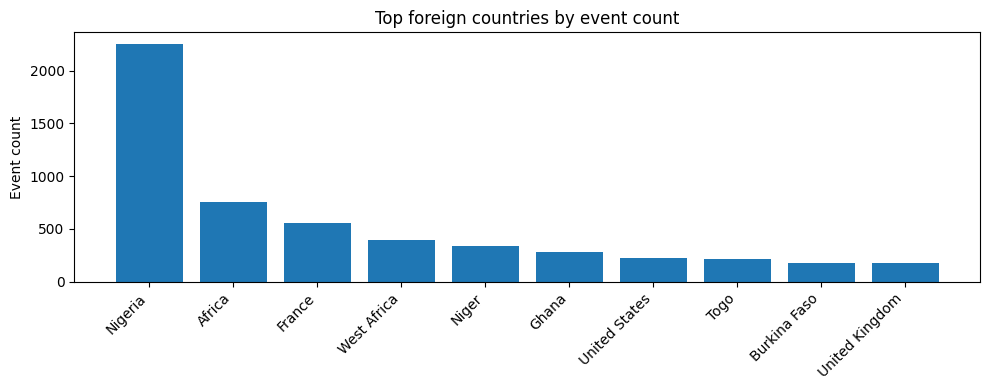

In [11]:
country_stats = defaultdict(lambda: {"count": 0, "tone_sum": 0.0})
for r in rows:
    country = (r.get("Actor1CountryLabel") or "").strip()
    if country and country.lower() != "benin":
        tone = to_float(r.get("AvgTone"))
        country_stats[country]["count"] += 1
        country_stats[country]["tone_sum"] += tone if tone is not None else 0.0

top_countries = sorted(country_stats.items(), key=lambda x: x[1]["count"], reverse=True)[:10]
print("Top foreign countries engaging with Benin")
for name, stats in top_countries:
    avg_tone = stats["tone_sum"] / stats["count"] if stats["count"] else 0.0
    print(f"- {name}: {stats['count']} events, AvgTone {avg_tone:.2f}")

if HAS_MPL and top_countries:
    labels = [c[0] for c in top_countries]
    values = [c[1]["count"] for c in top_countries]
    plt.figure(figsize=(10, 4))
    plt.bar(labels, values)
    plt.title("Top foreign countries by event count")
    plt.ylabel("Event count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Business and investment signal
- Events: 1493
- AvgTone: -0.64
- GoldsteinScale: 1.46
Top business-related foreign countries
- West Africa: 394 events
- Africa: 109 events
- Nigeria: 44 events
- Europe: 36 events
- Togo: 7 events
- France: 7 events
- United States: 7 events
- Ghana: 6 events


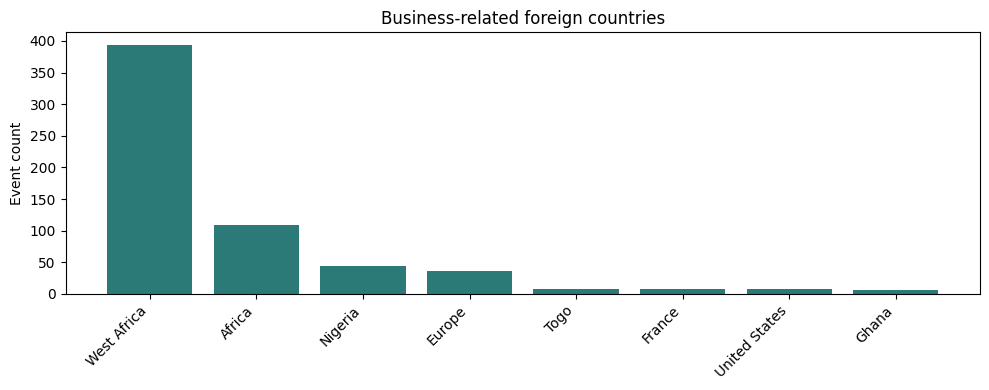

In [12]:
biz_codes = {"BUS", "DEV", "MNC", "IGO"}
biz_rows = []
for r in rows:
    t1 = (r.get("Actor1Type1Code") or "").strip()
    t2 = (r.get("Actor2Type1Code") or "").strip()
    if t1 in biz_codes or t2 in biz_codes:
        biz_rows.append(r)

biz_tones = [to_float(r.get("AvgTone")) for r in biz_rows]
biz_tones = [t for t in biz_tones if t is not None]
biz_gold = [to_float(r.get("GoldsteinScale")) for r in biz_rows]
biz_gold = [g for g in biz_gold if g is not None]

print("Business and investment signal")
print(f"- Events: {len(biz_rows)}")
if biz_tones:
    print(f"- AvgTone: {mean(biz_tones):.2f}")
if biz_gold:
    print(f"- GoldsteinScale: {mean(biz_gold):.2f}")

biz_country_stats = defaultdict(int)
for r in biz_rows:
    country = (r.get("Actor1CountryLabel") or "").strip()
    if country and country.lower() != "benin":
        biz_country_stats[country] += 1

top_biz = sorted(biz_country_stats.items(), key=lambda x: x[1], reverse=True)[:8]
print("Top business-related foreign countries")
for name, count in top_biz:
    print(f"- {name}: {count} events")

if HAS_MPL and top_biz:
    labels = [c[0] for c in top_biz]
    values = [c[1] for c in top_biz]
    plt.figure(figsize=(10, 4))
    plt.bar(labels, values, color="#2b7a78")
    plt.title("Business-related foreign countries")
    plt.ylabel("Event count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

QuadClass distribution
- Verbal Cooperation: 15495
- Material Conflict: 3290
- Verbal Conflict: 2629
- Material Cooperation: 2553


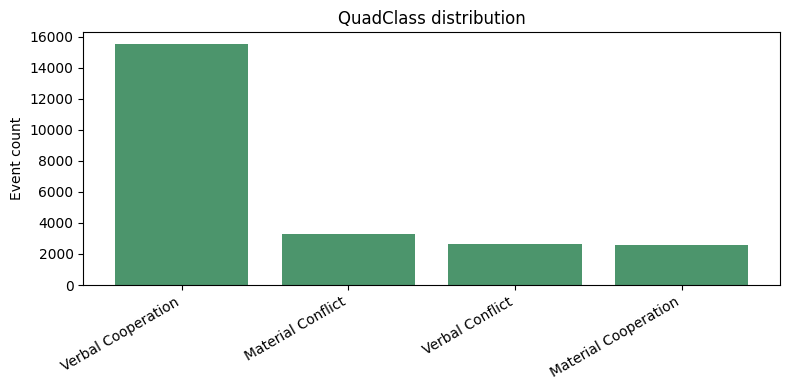

In [13]:
quad_stats = defaultdict(int)
for r in rows:
    label = (r.get("QuadClassLabel") or "").strip()
    if not label:
        label = (r.get("QuadClass") or "").strip()
    if label:
        quad_stats[label] += 1

quad_sorted = sorted(quad_stats.items(), key=lambda x: x[1], reverse=True)
print("QuadClass distribution")
for name, count in quad_sorted:
    print(f"- {name}: {count}")

if HAS_MPL and quad_sorted:
    labels = [q[0] for q in quad_sorted]
    values = [q[1] for q in quad_sorted]
    plt.figure(figsize=(8, 4))
    plt.bar(labels, values, color="#4c956c")
    plt.title("QuadClass distribution")
    plt.ylabel("Event count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

Monthly trend
- 2025-01: 2425 events, AvgTone -1.16
- 2025-02: 1572 events, AvgTone -1.35
- 2025-03: 1801 events, AvgTone -1.23
- 2025-04: 2116 events, AvgTone -1.01
- 2025-05: 1790 events, AvgTone -0.11
- 2025-06: 885 events, AvgTone -1.59
- 2025-07: 2030 events, AvgTone -0.72
- 2025-08: 1510 events, AvgTone -1.07
- 2025-09: 1435 events, AvgTone -0.65
- 2025-10: 1366 events, AvgTone -0.03
- 2025-11: 1695 events, AvgTone -0.49
- 2025-12: 5342 events, AvgTone -2.57


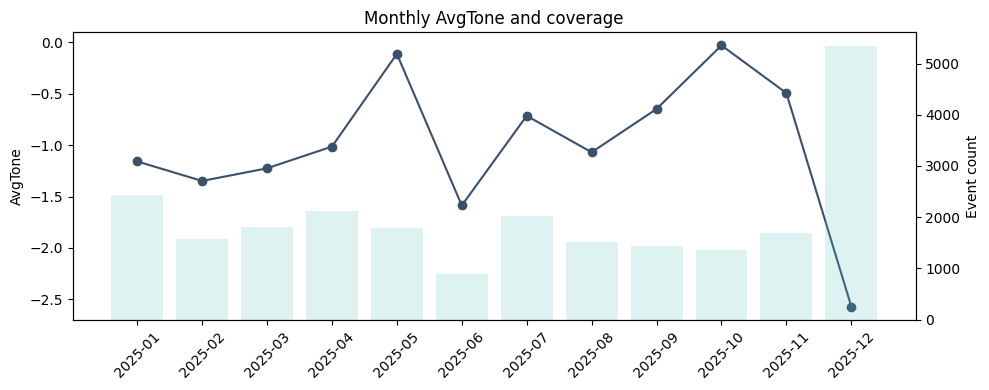

In [14]:
monthly_stats = defaultdict(lambda: {"count": 0, "tone_sum": 0.0})
for r in rows:
    month = (r.get("MonthYear") or "Unknown").strip()
    tone = to_float(r.get("AvgTone"))
    monthly_stats[month]["count"] += 1
    monthly_stats[month]["tone_sum"] += tone if tone is not None else 0.0

months = sorted(monthly_stats.keys())
counts = [monthly_stats[m]["count"] for m in months]
avg_tones = [monthly_stats[m]["tone_sum"] / monthly_stats[m]["count"] for m in months]

print("Monthly trend")
for m in months:
    avg_tone = monthly_stats[m]["tone_sum"] / monthly_stats[m]["count"]
    print(f"- {m}: {monthly_stats[m]['count']} events, AvgTone {avg_tone:.2f}")

if HAS_MPL and months:
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(months, avg_tones, marker="o", color="#3a506b")
    ax1.set_ylabel("AvgTone")
    ax1.set_title("Monthly AvgTone and coverage")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    ax2.bar(months, counts, alpha=0.2, color="#5bc0be")
    ax2.set_ylabel("Event count")

    fig.tight_layout()
    plt.show()

## Attractivity focus (EventRootLabel)
We summarize root event categories and highlight cooperation/aid/diplomacy signals that relate to attractiveness.

Top EventRoot categories
- CONSULT: 6476 events, AvgTone 0.15, Goldstein 2.51
- ENGAGE IN DIPLOMATIC COOPERATION: 3435 events, AvgTone 1.02, Goldstein 4.50
- MAKE PUBLIC STATEMENT: 2981 events, AvgTone -1.62, Goldstein 0.05
- APPEAL: 1624 events, AvgTone -1.17, Goldstein 2.98
- FIGHT: 1482 events, AvgTone -5.09, Goldstein -9.94
- DISAPPROVE: 1234 events, AvgTone -3.64, Goldstein -2.00
- EXPRESS INTENT TO COOPERATE: 979 events, AvgTone 0.10, Goldstein 4.30
- COERCE: 947 events, AvgTone -5.03, Goldstein -5.28
- PROVIDE AID: 837 events, AvgTone -0.29, Goldstein 7.50
- YIELD: 817 events, AvgTone -1.76, Goldstein 6.43

Attractivity-related root categories
- CONSULT: 6476 events, AvgTone 0.15, Goldstein 2.51
- ENGAGE IN DIPLOMATIC COOPERATION: 3435 events, AvgTone 1.02, Goldstein 4.50
- MAKE PUBLIC STATEMENT: 2981 events, AvgTone -1.62, Goldstein 0.05
- EXPRESS INTENT TO COOPERATE: 979 events, AvgTone 0.10, Goldstein 4.30
- PROVIDE AID: 837 events, AvgTone -0.29, Goldstein 7.50
- ENGAGE IN M

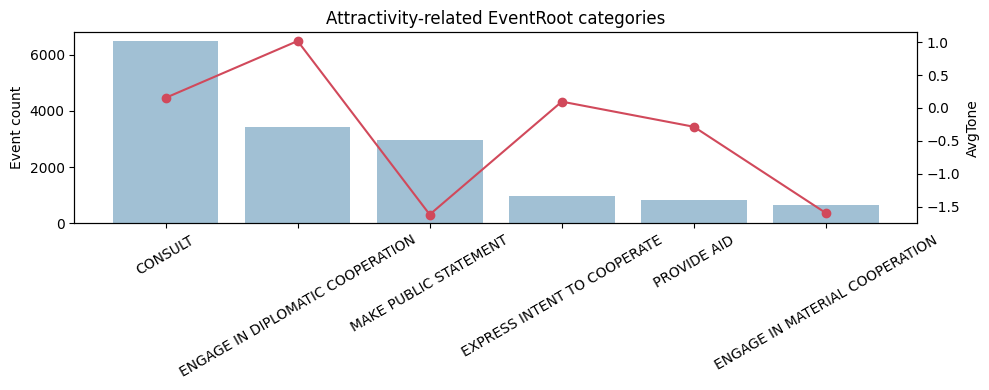

In [15]:
root_stats = defaultdict(lambda: {"count": 0, "tone_sum": 0.0, "gold_sum": 0.0})
for r in rows:
    root_label = (r.get("EventRootLabel") or "").strip()
    if not root_label:
        root_label = (r.get("EventRootCode") or "Unknown").strip()
    tone = to_float(r.get("AvgTone"))
    goldstein = to_float(r.get("GoldsteinScale"))
    root_stats[root_label]["count"] += 1
    root_stats[root_label]["tone_sum"] += tone if tone is not None else 0.0
    root_stats[root_label]["gold_sum"] += goldstein if goldstein is not None else 0.0

root_summary = []
for label, stats in root_stats.items():
    if stats["count"]:
        root_summary.append({
            "label": label,
            "count": stats["count"],
            "avg_tone": stats["tone_sum"] / stats["count"],
            "avg_gold": stats["gold_sum"] / stats["count"],
        })

root_summary = sorted(root_summary, key=lambda x: x["count"], reverse=True)
print("Top EventRoot categories")
for item in root_summary[:10]:
    print(f"- {item['label']}: {item['count']} events, AvgTone {item['avg_tone']:.2f}, Goldstein {item['avg_gold']:.2f}")

attractivity_roots = {
    "MAKE PUBLIC STATEMENT",
    "CONSULT",
    "ENGAGE IN DIPLOMATIC COOPERATION",
    "ENGAGE IN MATERIAL COOPERATION",
    "PROVIDE AID",
    "EXPRESS INTENT TO COOPERATE",
}
focus = [r for r in root_summary if r["label"].upper() in attractivity_roots]
print("\nAttractivity-related root categories")
for item in focus:
    print(f"- {item['label']}: {item['count']} events, AvgTone {item['avg_tone']:.2f}, Goldstein {item['avg_gold']:.2f}")

if HAS_MPL and focus:
    labels = [f["label"] for f in focus]
    counts = [f["count"] for f in focus]
    avg_tones = [f["avg_tone"] for f in focus]

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(labels, counts, color="#7aa6c2", alpha=0.7)
    ax1.set_ylabel("Event count")
    ax1.set_title("Attractivity-related EventRoot categories")
    ax1.tick_params(axis="x", rotation=30)

    ax2 = ax1.twinx()
    ax2.plot(labels, avg_tones, color="#d1495b", marker="o")
    ax2.set_ylabel("AvgTone")

    fig.tight_layout()
    plt.show()